## Part 1: Data Cleansing

#### Import Libraries

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

#### Load and Inspect the Dataset

In [158]:
df = pd.read_csv("car.csv")

print("Dataset Shape:", df.shape)

print("\nDataset Variables :")
df.info()

print("\nFirst 5 rows:")
df.head()

Dataset Shape: (398, 8)

Dataset Variables :
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    str    
 4   Weight        398 non-null    int64  
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   US Made       398 non-null    int64  
dtypes: float64(3), int64(4), str(1)
memory usage: 25.0 KB

First 5 rows:


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,US Made
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


#### Check for Missing Values

In [159]:
print("\nNull counts   :")
print(df.isnull().sum())


Null counts   :
MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
US Made         0
dtype: int64


#### Identify Missing Values Encoded as "?"

In [160]:
print("Rows where Horsepower == '?':")
print(df[df['Horsepower'] == '?'])

print(f"\nTotal missing Horsepower values: {(df['Horsepower'] == '?').sum()}")

Rows where Horsepower == '?':
      MPG  Cylinders  Displacement Horsepower  Weight  Acceleration  \
32   25.0          4          98.0          ?    2046          19.0   
126  21.0          6         200.0          ?    2875          17.0   
330  40.9          4          85.0          ?    1835          17.3   
336  23.6          4         140.0          ?    2905          14.3   
354  34.5          4         100.0          ?    2320          15.8   
374  23.0          4         151.0          ?    3035          20.5   

     Model Year  US Made  
32           71        1  
126          74        1  
330          80        0  
336          80        1  
354          81        0  
374          82        1  

Total missing Horsepower values: 6


Convert Horsepower to Numeric and Confirm Null Count

In [161]:
# Replace '?' with NaN and convert to float
df['Horsepower'] = pd.to_numeric(df['Horsepower'], errors='coerce')

print("Null counts after conversion:\n", df.isnull().sum())

Null counts after conversion:
 MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
US Made         0
dtype: int64


Impute Missing Horsepower Values

In [162]:
horsepower_median = df['Horsepower'].median()
print(f"Horsepower median used for imputation: {horsepower_median}")

df['Horsepower'] = df['Horsepower'].fillna(horsepower_median)

print("\nNull counts after imputation:\n", df.isnull().sum())

Horsepower median used for imputation: 93.5

Null counts after imputation:
 MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
US Made         0
dtype: int64


#### Check for Duplicate Rows

In [163]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Examine Unique Values and Data Ranges

In [164]:
summary = pd.DataFrame({
    'Unique Count': df.nunique(),
    'Data Type': df.dtypes
})

print(summary)


# Print unique values for all low-cardinality columns (reasonable to list)
for col in df.columns:
    if df[col].nunique() <= 15:
        print(f"\n{col} unique values: {sorted(df[col].unique())}")
    else:
        print(f"\n{col}: {df[col].nunique()} unique values (continuous) — "
              f"range [{df[col].min()}, {df[col].max()}]")


              Unique Count Data Type
MPG                    129   float64
Cylinders                5     int64
Displacement            82   float64
Horsepower              94   float64
Weight                 351     int64
Acceleration            95   float64
Model Year              13     int64
US Made                  2     int64

MPG: 129 unique values (continuous) — range [9.0, 46.6]

Cylinders unique values: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8)]

Displacement: 82 unique values (continuous) — range [68.0, 455.0]

Horsepower: 94 unique values (continuous) — range [46.0, 230.0]

Weight: 351 unique values (continuous) — range [1613, 5140]

Acceleration: 95 unique values (continuous) — range [8.0, 24.8]

Model Year unique values: [np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82)]

US Made unique values: [np.int64(0), np.int64(1)]

#### Descriptive Summary

In [165]:

df.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,US Made
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,0.625628
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.484569
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,0.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,0.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,1.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,1.000000


#### Outlier Detection

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
MPG,17.50,29.00,11.50,0.25,46.25,1.0
Cylinders,4.00,8.00,4.00,-2.00,14.00,0.0
Displacement,104.25,262.00,157.75,-132.38,498.62,0.0
Horsepower,76.00,125.00,49.00,2.50,198.50,11.0
Weight,2223.75,3608.00,1384.25,147.38,5684.38,0.0
Acceleration,13.82,17.18,3.35,8.80,22.20,7.0
Model Year,73.00,79.00,6.00,64.00,88.00,0.0
US Made,0.00,1.00,1.00,-1.50,2.50,0.0


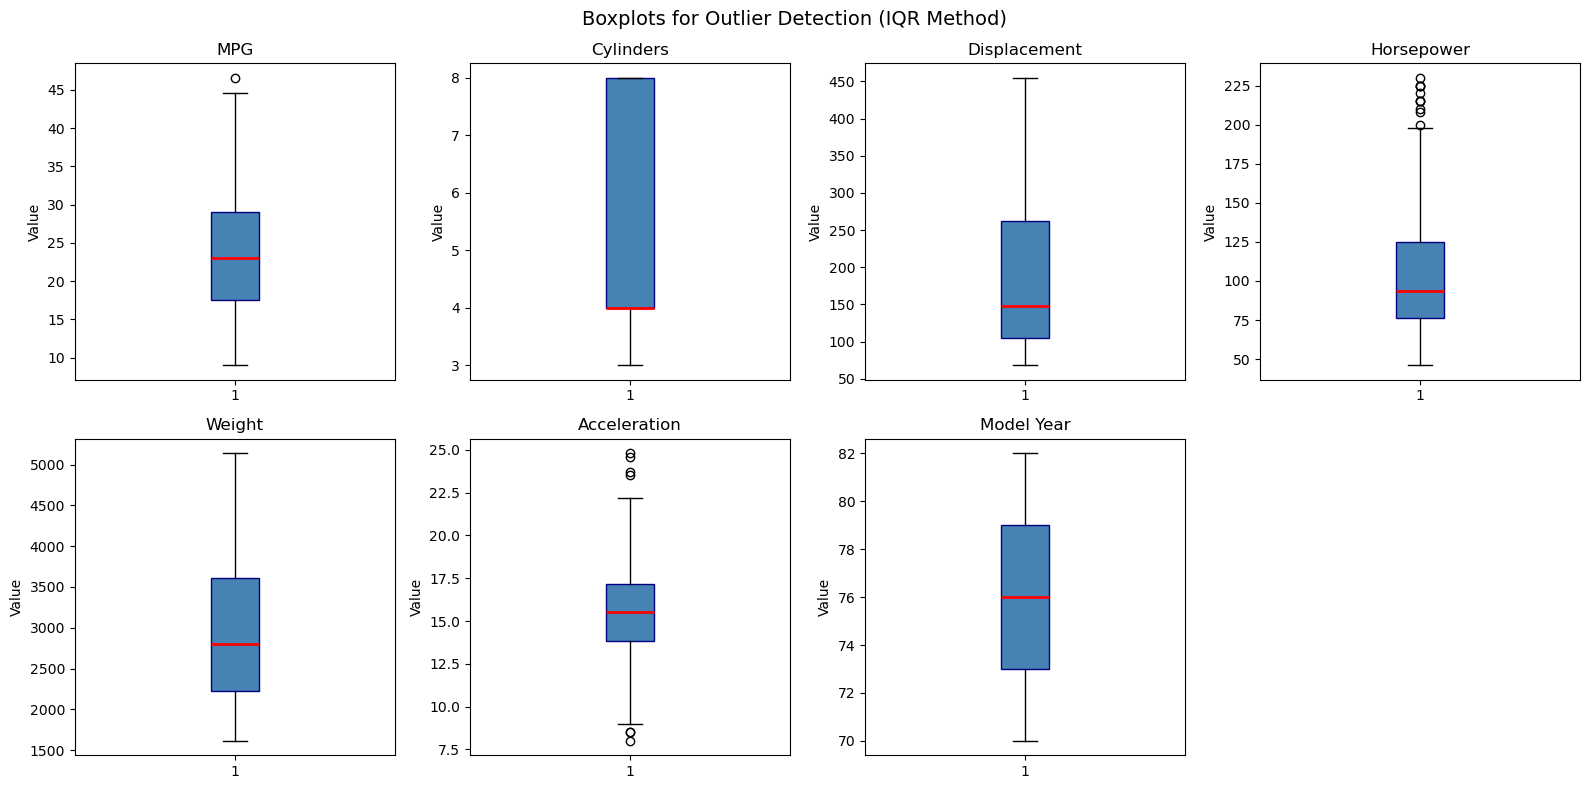

In [166]:
outlier_summary = {}

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    }

summary_df = pd.DataFrame(outlier_summary).T.round(2)
display(summary_df)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Value')

axes[-1].set_visible(False)
plt.suptitle("Boxplots for Outlier Detection (IQR Method)", fontsize=14)
plt.tight_layout()
plt.show()

#### Visualize Distributions and Check for Skewness

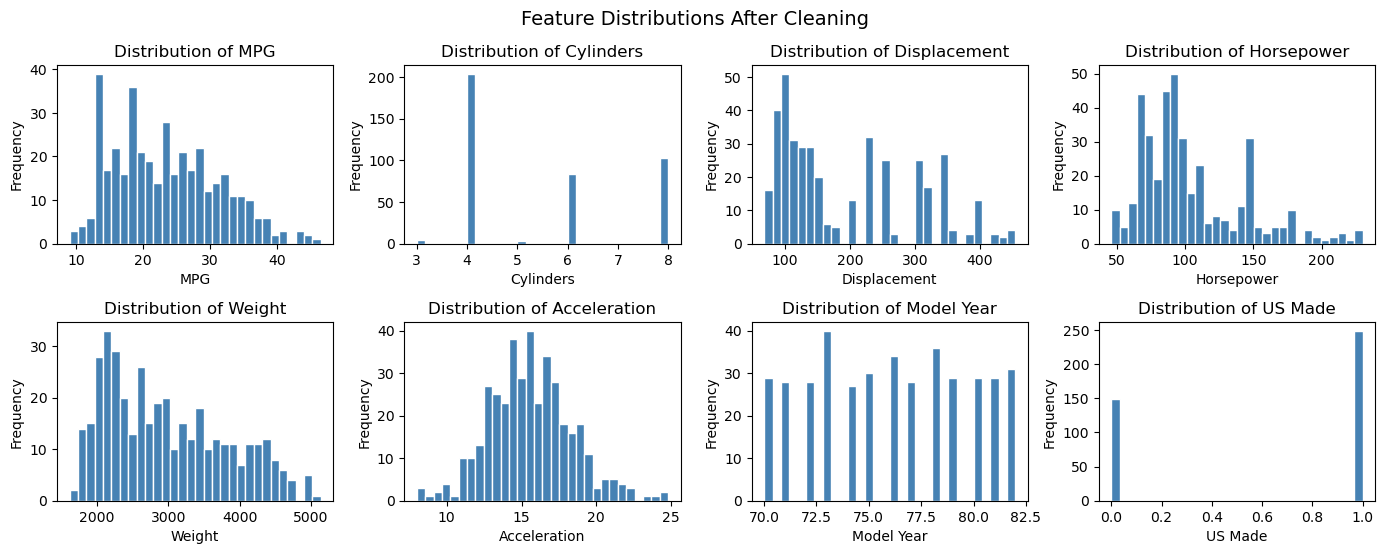

In [167]:
numeric_cols = df.columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle("Feature Distributions After Cleaning", y=1.02, fontsize=14)
plt.show()

#### Final Cleaned Dataset Summary

In [168]:
print("Cleaned Dataset Shape:", df.shape)

print("\nCleaned Dataset Variables :")
df.info()

print("\nFirst 5 rows:")
df.head()

Cleaned Dataset Shape: (398, 8)

Cleaned Dataset Variables :
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    float64
 4   Weight        398 non-null    int64  
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   US Made       398 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 25.0 KB

First 5 rows:


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,US Made
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


In [169]:
print('Missing Value Count:\n', df.isnull().sum())

Missing Value Count:
 MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
US Made         0
dtype: int64


## Part 2: Building the Linear Regression Model

#### Examine Correlations Before Modeling

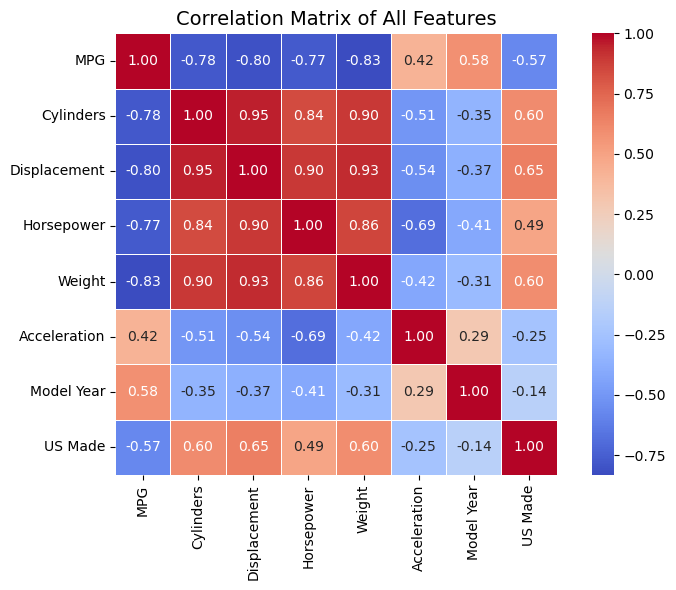


Correlation with MPG:
 Weight         -0.831741
Displacement   -0.804203
Cylinders      -0.775396
Horsepower     -0.773453
US Made        -0.568192
Acceleration    0.420289
Model Year      0.579267
MPG             1.000000
Name: MPG, dtype: float64


In [170]:
correlation_matrix = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            square=True, linewidths=0.5)
plt.title("Correlation Matrix of All Features", fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelation with MPG:\n", correlation_matrix['MPG'].sort_values())

#### Define Features and Target Variable

In [171]:
X = df.drop(columns=['MPG'])
y = df['MPG']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nFeatures used:\n", X.columns.tolist())

Feature matrix shape: (398, 7)
Target vector shape: (398,)

Features used:
 ['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'US Made']


####  Split Data into Training and Test Sets

In [172]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (318, 7)
Test set size: (80, 7)


#### Fit the Linear Regression Model

In [173]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("\nCoefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

Intercept: -18.740285383052672

Coefficients:
  Cylinders: -0.1762
  Displacement: 0.0197
  Horsepower: -0.0152
  Weight: -0.0070
  Acceleration: 0.0675
  Model Year: 0.8216
  US Made: -2.8045


#### Evaluate Model on the Test Set

In [174]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"Test R-squared:          {r2:.4f}")
print(f"Test Adjusted R-squared: {adj_r2:.4f}")
print(f"Test MSE:                {mse:.4f}")
print(f"Test RMSE:               {rmse:.4f}")
print(f"Test MAE:                {mae:.4f}")

Test R-squared:          0.8463
Test Adjusted R-squared: 0.8313
Test MSE:                8.2650
Test RMSE:               2.8749
Test MAE:                2.2620


#### Visualize Actual vs Predicted MPG

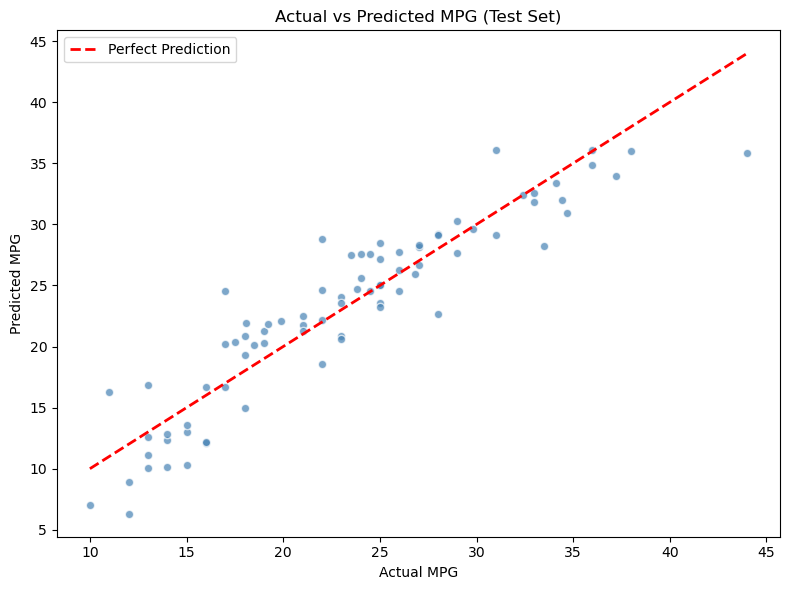

In [175]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7, edgecolors='white')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

#### Residual Analysis

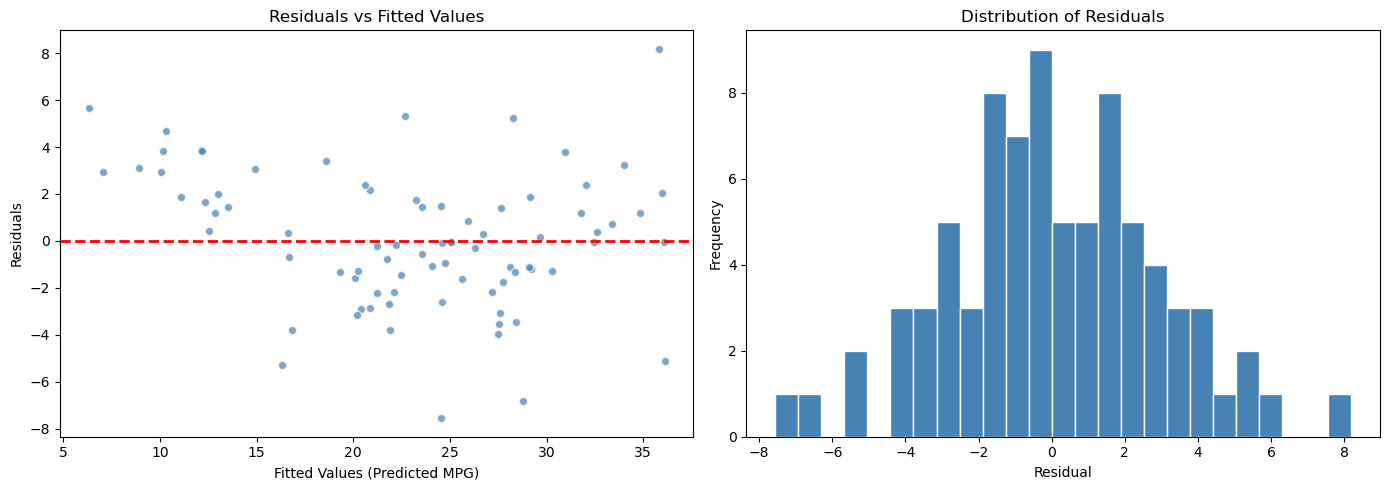

Residual mean: 0.0806
Residual std:  2.8919


In [176]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(y_pred, residuals, color='steelblue', alpha=0.7, edgecolors='white')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel("Fitted Values (Predicted MPG)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted Values")

# Histogram of residuals
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white')
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.4f}")

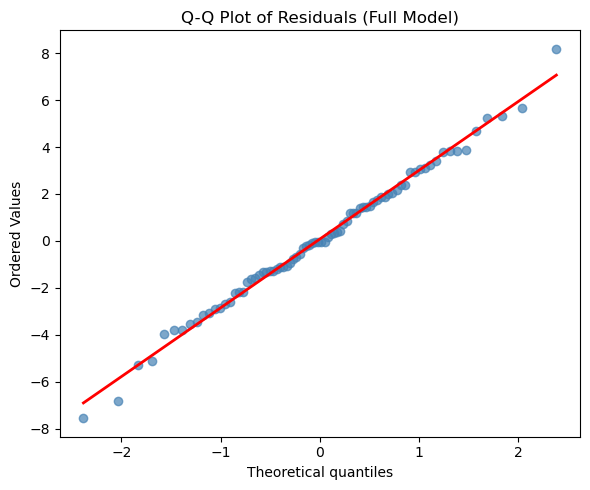

In [177]:
# Q-Q Plot for Residuals (Full Model)
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Residuals (Full Model)")
ax.get_lines()[0].set(color='steelblue', alpha=0.7)
ax.get_lines()[1].set(color='red', linewidth=2)
plt.tight_layout()
plt.show()

#### Coefficient Interpretation + P-Values via Scipy

     Feature  Coefficient  Std Error  T-Statistic      P-Value
     US Made    -2.804507   0.555904    -5.044945 7.740443e-07
   Cylinders    -0.176177   0.377095    -0.467194 6.406894e-01
  Horsepower    -0.015214   0.015498    -0.981680 3.270228e-01
      Weight    -0.006993   0.000728    -9.603741 0.000000e+00
Displacement     0.019706   0.008891     2.216573 2.737790e-02
Acceleration     0.067460   0.109584     0.615604 5.386074e-01
  Model Year     0.821615   0.060175    13.653784 0.000000e+00


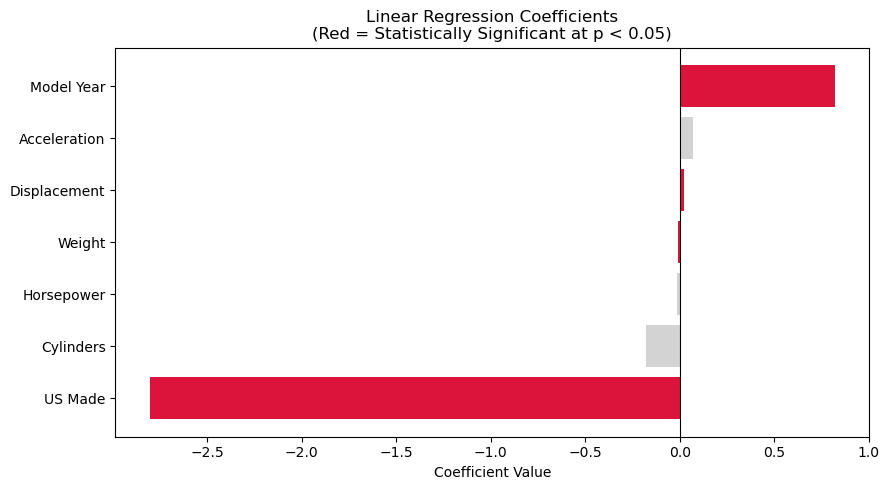

In [178]:
from scipy import stats

# Calculate p-values manually
X_train_arr = X_train.values
y_train_arr = y_train.values
y_train_pred = model.predict(X_train)

n = X_train_arr.shape[0]
k = X_train_arr.shape[1]

residuals_train = y_train_arr - y_train_pred
rss = np.sum(residuals_train ** 2)
s2 = rss / (n - k - 1)

X_with_const = np.column_stack([np.ones(n), X_train_arr])
var_coef = s2 * np.linalg.inv(X_with_const.T @ X_with_const).diagonal()
se = np.sqrt(var_coef[1:])

t_stats = model.coef_ / se
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k - 1))

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_,
    'Std Error': se,
    'T-Statistic': t_stats,
    'P-Value': p_values
}).sort_values('Coefficient')

print(coef_df.to_string(index=False))

# Plot
plt.figure(figsize=(9, 5))
colors = ['crimson' if p < 0.05 else 'lightgray' for p in coef_df['P-Value']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("Linear Regression Coefficients\n(Red = Statistically Significant at p < 0.05)")
plt.tight_layout()
plt.show()

In [179]:
# 95% Confidence Intervals for Full Model Coefficients
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, df=n - k - 1)

ci_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_,
    'Lower 95% CI': model.coef_ - t_critical * se,
    'Upper 95% CI': model.coef_ + t_critical * se
})
print("95% Confidence Intervals:")
print(ci_df.to_string(index=False))

95% Confidence Intervals:
     Feature  Coefficient  Lower 95% CI  Upper 95% CI
   Cylinders    -0.176177     -0.918167      0.565814
Displacement     0.019706      0.002213      0.037200
  Horsepower    -0.015214     -0.045709      0.015281
      Weight    -0.006993     -0.008426     -0.005560
Acceleration     0.067460     -0.148162      0.283082
  Model Year     0.821615      0.703212      0.940017
     US Made    -2.804507     -3.898330     -1.710684


## Part 3: Model Optimization, Feature Selection, and Design Recommendations

#### Check for Multicollinearity Using VIF

In [180]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) 
                   for i in range(X_train.shape[1])]

print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

     Feature        VIF
      Weight 131.528467
   Cylinders 119.454187
  Model Year 109.611403
Displacement 101.132151
Acceleration  67.285625
  Horsepower  61.566945
     US Made   5.196780


#### Backward Elimination Based on P-Values

In [181]:
selected_features = X_train.columns.tolist()

while True:
    # Fit model on current features
    X_temp = X_train[selected_features].values
    n = X_temp.shape[0]
    k = X_temp.shape[1]
    
    temp_model = LinearRegression()
    temp_model.fit(X_temp, y_train)
    
    y_temp_pred = temp_model.predict(X_temp)
    residuals_temp = y_train.values - y_temp_pred
    rss = np.sum(residuals_temp ** 2)
    s2 = rss / (n - k - 1)
    
    X_with_const = np.column_stack([np.ones(n), X_temp])
    var_coef = s2 * np.linalg.inv(X_with_const.T @ X_with_const).diagonal()
    se = np.sqrt(var_coef[1:])
    t_stats = temp_model.coef_ / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k - 1))
    
    max_p = np.max(p_values)
    
    if max_p > 0.05:
        worst_feature = selected_features[np.argmax(p_values)]
        print(f"Removing '{worst_feature}' with p-value: {max_p:.4f}")
        selected_features.remove(worst_feature)
    else:
        print(f"\nAll remaining features are significant (p < 0.05).")
        break

print(f"\nSelected features after backward elimination: {selected_features}")

Removing 'Cylinders' with p-value: 0.6407
Removing 'Acceleration' with p-value: 0.5223
Removing 'Horsepower' with p-value: 0.0910
Removing 'Displacement' with p-value: 0.0589

All remaining features are significant (p < 0.05).

Selected features after backward elimination: ['Weight', 'Model Year', 'US Made']


#### Fit the Optimized Model on Selected Features

In [182]:
X_train_opt = X_train[selected_features]
X_test_opt = X_test[selected_features]

optimized_model = LinearRegression()
optimized_model.fit(X_train_opt, y_train)

y_pred_opt = optimized_model.predict(X_test_opt)

r2_opt = r2_score(y_test, y_pred_opt)
adj_r2_opt = 1 - (1 - r2_opt) * (len(y_test) - 1) / (len(y_test) - len(selected_features) - 1)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
mae_opt = mean_absolute_error(y_test, y_pred_opt)

print("Optimized Model Performance:")
print(f"  R-squared:          {r2_opt:.4f}")
print(f"  Adjusted R-squared: {adj_r2_opt:.4f}")
print(f"  RMSE:               {rmse_opt:.4f}")
print(f"  MAE:                {mae_opt:.4f}")

Optimized Model Performance:
  R-squared:          0.8388
  Adjusted R-squared: 0.8324
  RMSE:               2.9441
  MAE:                2.2943


#### Compare Full Model vs Optimized Model

            Metric  Full Model  Optimized Model
         R-Squared    0.846280         0.838789
Adjusted R-Squared    0.831335         0.832426
              RMSE    2.874891         2.944101
               MAE    2.262022         2.294348


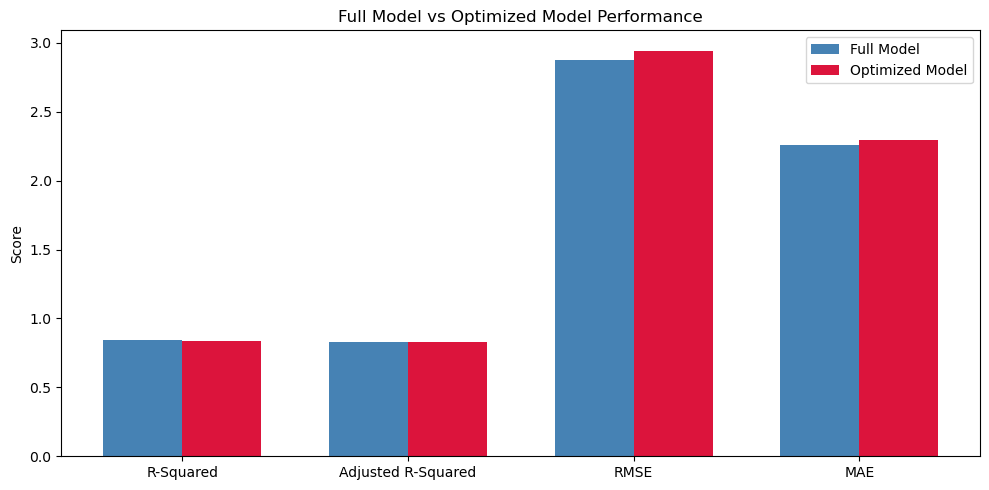

In [183]:
comparison_df = pd.DataFrame({
    'Metric': ['R-Squared', 'Adjusted R-Squared', 'RMSE', 'MAE'],
    'Full Model': [r2, adj_r2, rmse, mae],
    'Optimized Model': [r2_opt, adj_r2_opt, rmse_opt, mae_opt]
})

print(comparison_df.to_string(index=False))

# Bar chart comparison
x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, comparison_df['Full Model'], width, 
               label='Full Model', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df['Optimized Model'], width, 
               label='Optimized Model', color='crimson')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'])
ax.set_ylabel('Score')
ax.set_title('Full Model vs Optimized Model Performance')
ax.legend()
plt.tight_layout()
plt.show()

#### Optimized Model Coefficients and Feature Importance

   Feature  Coefficient  P-Value
   US Made    -2.158370 0.000019
    Weight    -0.005967 0.000000
Model Year     0.806956 0.000000


c:\Users\LENOVO\anaconda3\envs\analytics\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


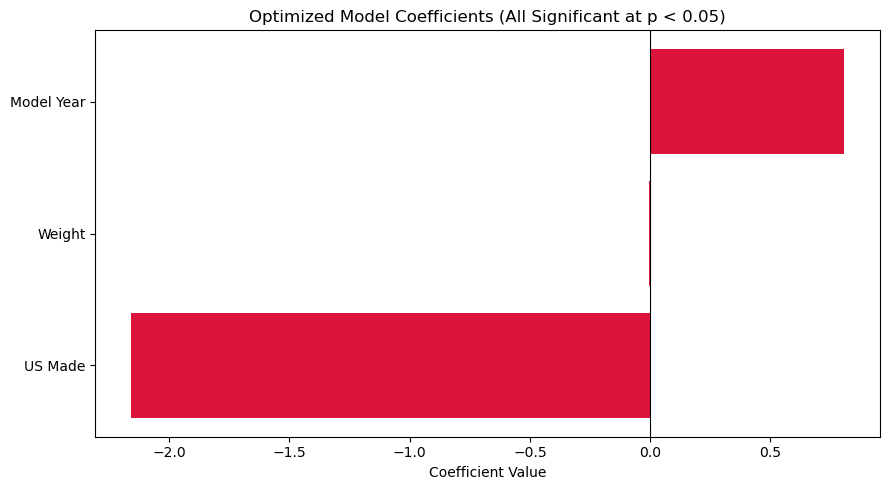

In [184]:
# Recalculate p-values for optimized model
X_opt_arr = X_train_opt.values
y_opt_pred_train = optimized_model.predict(X_opt_arr)
n_opt = X_opt_arr.shape[0]
k_opt = X_opt_arr.shape[1]

residuals_opt = y_train.values - y_opt_pred_train
rss_opt = np.sum(residuals_opt ** 2)
s2_opt = rss_opt / (n_opt - k_opt - 1)

X_opt_const = np.column_stack([np.ones(n_opt), X_opt_arr])
var_coef_opt = s2_opt * np.linalg.inv(X_opt_const.T @ X_opt_const).diagonal()
se_opt = np.sqrt(var_coef_opt[1:])
t_stats_opt = optimized_model.coef_ / se_opt
p_values_opt = 2 * (1 - stats.t.cdf(np.abs(t_stats_opt), df=n_opt - k_opt - 1))

coef_opt_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': optimized_model.coef_,
    'P-Value': p_values_opt
}).sort_values('Coefficient')

print(coef_opt_df.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(coef_opt_df['Feature'], coef_opt_df['Coefficient'], color='crimson')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel("Coefficient Value")
plt.title("Optimized Model Coefficients (All Significant at p < 0.05)")
plt.tight_layout()
plt.show()

####  Residual Analysis on Optimized Model

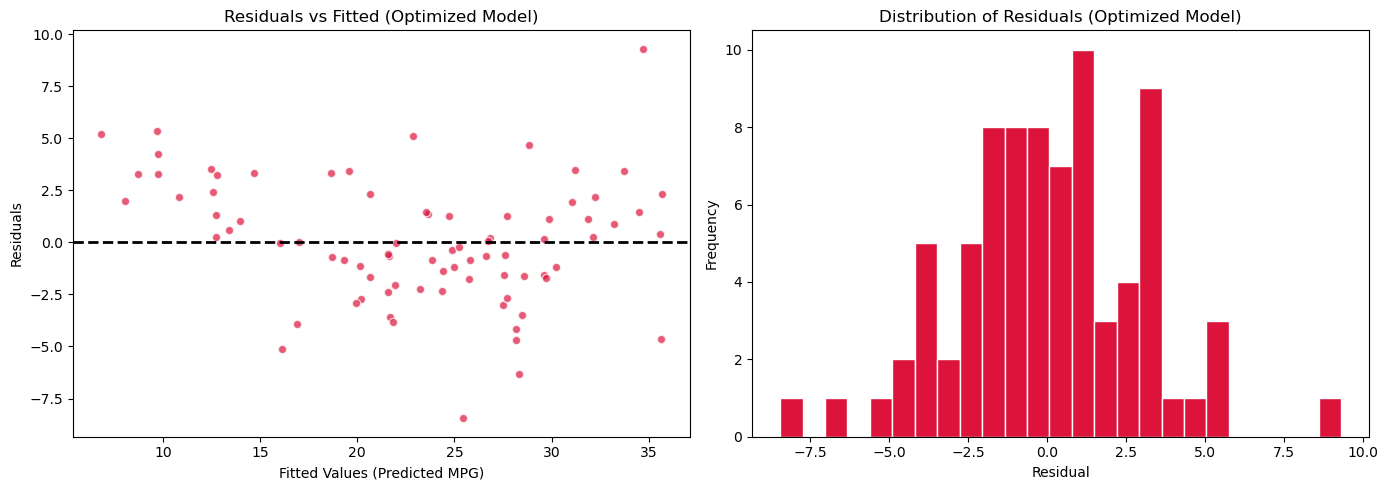

Residual mean: 0.0520
Residual std:  2.9622


In [185]:
residuals_final = y_test - y_pred_opt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_opt, residuals_final, color='crimson', alpha=0.7, edgecolors='white')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0].set_xlabel("Fitted Values (Predicted MPG)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (Optimized Model)")

axes[1].hist(residuals_final, bins=25, color='crimson', edgecolor='white')
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Residuals (Optimized Model)")

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals_final.mean():.4f}")
print(f"Residual std:  {residuals_final.std():.4f}")

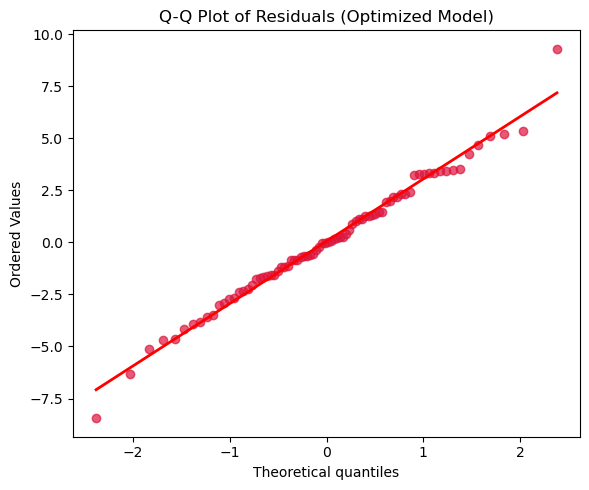

In [189]:
# Q-Q Plot for Residuals (Optimized Model)
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(residuals_final, dist="norm", plot=ax)  # changed variable
ax.set_title("Q-Q Plot of Residuals (Optimized Model)")  # changed title
ax.get_lines()[0].set(color='crimson', alpha=0.7)
ax.get_lines()[1].set(color='red', linewidth=2)
plt.tight_layout()
plt.show()

### Final Design Recommendations for the Manufacturer

In [187]:
print("=" * 60)
print("DESIGN RECOMMENDATIONS FOR IMPROVED FUEL EFFICIENCY")
print("=" * 60)

for _, row in coef_opt_df.sort_values('Coefficient').iterrows():
    direction = "DECREASE" if row['Coefficient'] < 0 else "INCREASE"
    print(f"  {direction} {row['Feature']:<15} | Coefficient: {row['Coefficient']:+.4f}")

print("=" * 60)

DESIGN RECOMMENDATIONS FOR IMPROVED FUEL EFFICIENCY
  DECREASE US Made         | Coefficient: -2.1584
  DECREASE Weight          | Coefficient: -0.0060
  INCREASE Model Year      | Coefficient: +0.8070


In [188]:
# Worked Example: Predicting MPG for a Proposed Vehicle Design
print("=" * 60)
print("WORKED PREDICTION EXAMPLE")
print("=" * 60)

# Define a proposed vehicle configuration
proposed_vehicle = pd.DataFrame({
    'Weight':     [2800],   # lightweight target: 2800 lbs
    'Model Year': [82],     # most recent model year in dataset
    'US Made':    [0]       # foreign-equivalent engineering standard
})

predicted_mpg = optimized_model.predict(proposed_vehicle)[0]
print(f"\nProposed configuration:")
print(f"  Weight:     2800 lbs")
print(f"  Model Year: 82 (1982 equivalent)")
print(f"  US Made:    0 (foreign-standard engineering)")
print(f"\nPredicted MPG: {predicted_mpg:.2f}")

# Compare to a typical heavy US vehicle in the dataset
typical_vehicle = pd.DataFrame({
    'Weight':     [4000],
    'Model Year': [70],
    'US Made':    [1]
})

typical_mpg = optimized_model.predict(typical_vehicle)[0]
print(f"\nTypical heavy US vehicle (1970, 4000 lbs):")
print(f"  Predicted MPG: {typical_mpg:.2f}")
print(f"\nEstimated MPG improvement: +{predicted_mpg - typical_mpg:.2f} MPG")
print("=" * 60)

WORKED PREDICTION EXAMPLE

Proposed configuration:
  Weight:     2800 lbs
  Model Year: 82 (1982 equivalent)
  US Made:    0 (foreign-standard engineering)

Predicted MPG: 30.70

Typical heavy US vehicle (1970, 4000 lbs):
  Predicted MPG: 11.70

Estimated MPG improvement: +19.00 MPG
